In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# The reservior staorage is half in some basins
# Create the DataFrame
basin_df = pd.DataFrame({
    "Area": {
        "dsk": 18658.8,
        "hsg": 4316.58,
        "kq": 46986.12,
        "slglk": 19275.39,
        "tgzlk": 14811.93,
        "wlwt": 38722.68,
        "xhl": 12948.48
    },
    "Storage": {
        "dsk": 206905000,
        "hsg": 206905000,
        "kq": 4674390000,  # corrected value from your input
        "slglk": 149195000,
        "tgzlk": 320170000,
        "wlwt": 320170000,
        "xhl": 149195000
    }
})

print(basin_df)


           Area     Storage
dsk    18658.80   206905000
hsg     4316.58   206905000
kq     46986.12  4674390000
slglk  19275.39   149195000
tgzlk  14811.93   320170000
wlwt   38722.68   320170000
xhl    12948.48   149195000


In [3]:
# Mapping from region → stations
region_to_stations = {
    "Aksu": ["xhl",'slglk'],
    "Bayingol": ["hsg", "dsk"],
    "Hotan": ["wlwt", "tgzlk"],
    "Kashgar": ["kq"]
}

In [4]:
Eco_series = pd.Series(
    {
        "Bayingol": 1.148,
        "Aksu": 1.499,
        "Kashgar": 1.424,
        "Hotan": 1.195
    },
    name="Eco_value"
)


In [5]:
station_list = ['hsg', 'dsk', 'xhl', 'slglk', 'kq', 'wlwt', 'tgzlk']

In [6]:
for i, scenario in enumerate(['ssp126','ssp245','ssp370','ssp585']):
    Q_P_gr_dict = {}   # empty dictionary to store results

    for j, station in enumerate(station_list):
        station_df = pd.read_csv(
            rf"F:\geodata\river_runoff_obs\output\{j+1}_{station}_imputMF_mean_ssp370_r1i1p1f1_daily_fixed.csv",
            index_col=0
        )
        station_df.index = pd.to_datetime(station_df.index)
        area = basin_df.loc[station, 'Area']   # in m²
        # station_df['pre_daily'] *= (10 * area * 1_000_000 / 86400)
        station_df['pre_daily'] *= (10  * area * 10**6 / 86400 )
        # station_df['ep_fixed'] *= (10  * area * 10**6 / 86400 /100)

        annual_station_df = station_df.resample('YE').mean()
        annual_station_df['gr'] *= (12 / 365 / 24 / 60 / 60)

        # calculate FRSS
        annual_station_df['Q_P_gr'] =annual_station_df['runoff_fixed']-annual_station_df['pre_daily']-annual_station_df['gr']
        # store the FRSS series for this station
        Q_P_gr_dict[station] = annual_station_df['Q_P_gr']

    # Combine into one DataFrame (columns = stations, index = years)
    Q_P_gr_df = pd.DataFrame(Q_P_gr_dict)
    Q_P_gr_df.index = range(2000,2101)
    Q_P_gr_df.index.name = 'year'

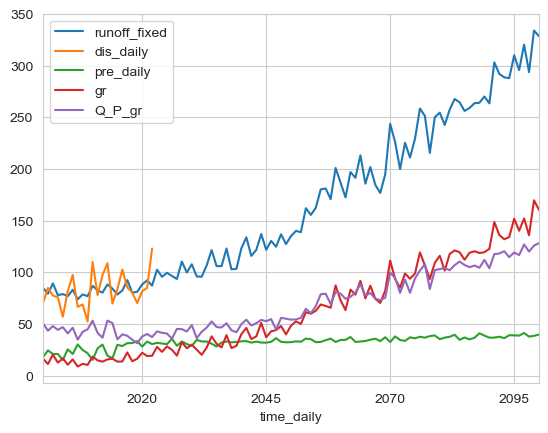

In [7]:
annual_station_df[['runoff_fixed','dis_daily','pre_daily','gr','Q_P_gr']].plot()
plt.show()

In [8]:
Q_P_gr_df

,hsg,dsk,xhl,slglk,kq,wlwt,tgzlk
year,,,,,,,
2000,9.593673,105.059750,105.149329,74.990885,123.047831,-6.692879,50.721449
2001,6.545142,94.047223,95.813210,61.787952,120.400659,-24.884391,43.529503
2002,8.619439,106.565906,99.685693,67.186438,134.306904,-14.957966,47.967946
2003,4.854277,85.231749,96.098127,71.733654,96.622555,-23.603563,44.355370
2004,5.117585,88.153208,92.481640,73.296849,104.433125,-8.676506,46.978011
...,...,...,...,...,...,...,...
2096,6.697965,101.075068,129.397257,67.033027,283.535062,3.197715,116.723938
2097,4.347787,94.598980,124.434398,62.497431,273.415256,6.949312,126.899679
2098,5.133511,97.338247,126.555078,60.380319,293.052421,17.830045,120.073439
